In [17]:
# Load required libraries
library(tidyverse)
library(progress)
# if not install mvtnorm, install it
if (!require("mvtnorm")) {
  install.packages("mvtnorm")
}
library(mvtnorm)


Rows: 128 Columns: 128
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (128): X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


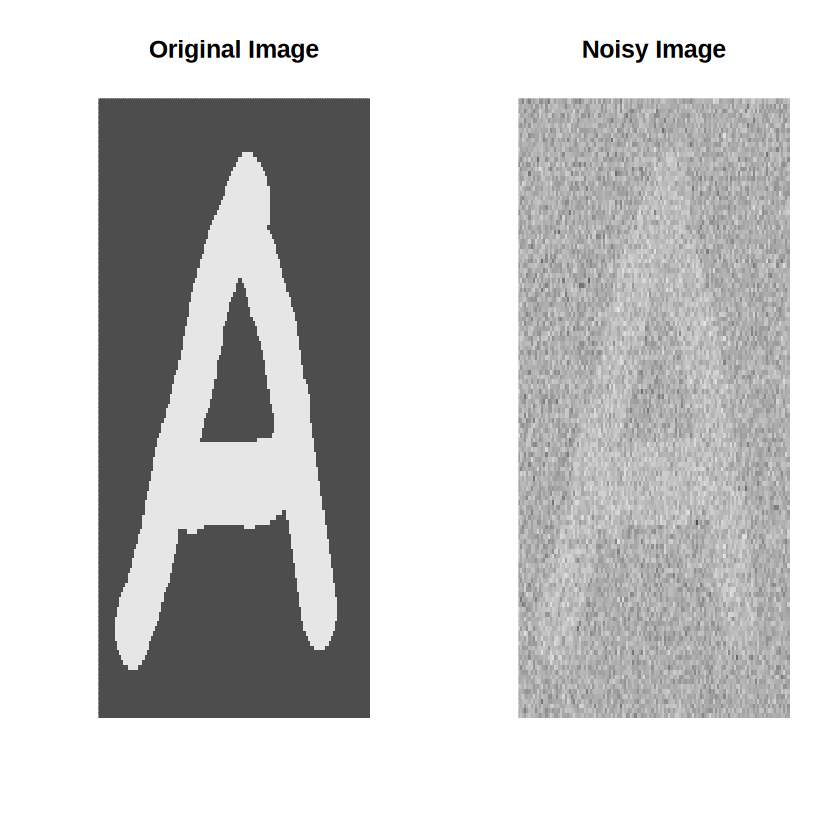

In [18]:
# fix the random seed, ensuring reproducibility
set.seed(1)

# set the parameters
sigma <- 2

# read and preprocess the image
img <- read_csv("https://raw.githubusercontent.com/aqlkzf/STAT6205/refs/heads/main/Assignment2/data/letterA.csv", 
                col_names = FALSE)
img <- as.matrix(img)
mean_val <- mean(img)
# binarize the image using the mean value
img2 <- ifelse(img >= mean_val, 1, -1)
# add noise to the image
y <- img2 + sigma * matrix(rnorm(length(img2)), nrow = nrow(img2), ncol = ncol(img2))

# Create plot of original and noisy images

par(mfrow = c(1, 2))
image(t(img2[nrow(img2):1,]), col = grey.colors(256), axes = FALSE, main = "Original Image")
image(t(y[nrow(y):1,]), col = grey.colors(256), axes = FALSE, main = "Noisy Image")


In [19]:
# print y shape
print(dim(y))


[1] 128 128


In [20]:
# load beta_s
beta_s <- read.csv("https://raw.githubusercontent.com/aqlkzf/STAT6205/refs/heads/main/Assignment2/data/beta_s.csv")

# print beta_s shape
print(dim(beta_s))

[1] 128 128


In [21]:
# please use y as the noised image and beta_s to do the assignment

In [22]:
# set the iteration times
iters <- c(82000, 163000, 245000, 330000, 500000, 600000)
print(iters)

meanfield <- function(img, beta = 1, niter = 10, beta_s = NULL) {

  return(img)
}

gibbs <- function(img, beta = 1, niter = 10, beta_s = NULL) {

  return(img)
}

[1]  82000 163000 245000 330000 500000 600000


In [23]:
# This is the function to plot the result
# You can use and modify this function to plot the result
# Replace result <- meanfield(y, 1, niter = iters[i], beta_s = beta_s) with your result

# plot the Mean Field denoising results
pdf("meanFieldDenoising.pdf", width = 4 * length(iters), height = 7)
par(mfrow = c(1, length(iters)), mar = c(2, 2, 6, 2))
for (i in seq_along(iters)) {
  result <- meanfield(y, 1, niter = iters[i], beta_s = beta_s)
  result <- t(result[nrow(result):1, ])

  image(result, col = grey.colors(256), axes = FALSE, main = paste("iter =", iters[i]))
}
mtext("Mean Field (pixel-level updates)", side = 3, outer = TRUE, line = -1.5, cex = 1.6)
dev.off()

agg_record_654578780 
                   2

In [24]:
# This is the function to plot the Gibbs sampling result
# You can use and modify this function to plot the result

# plot the Gibbs Sampling denoising results
pdf("gibbsDenoising.pdf", width = 4 * length(iters), height = 7)
par(mfrow = c(1, length(iters)), mar = c(2, 2, 6, 2))
for (i in seq_along(iters)) {
  result <- gibbs(y, 1, niter = iters[i], beta_s = beta_s)
  result <- t(result[nrow(result):1, ])

  image(result, col = grey.colors(256), axes = FALSE, main = paste("iter =", iters[i]))
}
mtext("Gibbs Sampling (pixel-level updates)", side = 3, outer = TRUE, line = -1.5, cex = 1.6)
dev.off()

agg_record_437039496 
                   2